# 01 — Exploratory Data Analysis

**Goal:** understand the Severson dataset before modeling — what each cell's degradation looks like,
how cycle life is distributed, and *why* a feature built from the first 100 cycles can predict it.

All plotting logic lives in `src/visualization/plots.py`; this notebook just calls it, so the
figures are reproducible from a script (`python -m src.visualization.plots`).

> Run `make download && make process` first to build `data/processed/`.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
from src.data.dataset import load_processed
from src.visualization import plots

ds = load_processed()
print(f"{len(ds.cells)} cells | splits: {ds.cells['split'].value_counts().to_dict()}")
ds.cells.head()

124 cells | splits: {'test': 43, 'train': 41, 'secondary_test': 40}


,cell_id,batch,cycle_life,charge_policy,split
0,b1c0,1,1852.0,3.6C(80%)-3.6C,test
1,b1c1,1,2160.0,3.6C(80%)-3.6C,train
2,b1c2,1,2237.0,3.6C(80%)-3.6C,test
3,b1c3,1,1434.0,4C(80%)-4C,train
4,b1c4,1,1709.0,4C(80%)-4C,test


## 1. Capacity fade per cell

Each line is one cell losing discharge capacity as it cycles. The dashed line is the
**End-of-Life threshold (0.88 Ah = 80 % of the 1.1 Ah nominal)** — the cycle at which a curve
crosses it *is* the cycle life we predict. Lines are colored by cycle life: note how little the
curves separate in the **first ~100 cycles**, which is the whole challenge — we must predict the
eventual lifetime before the fade is visually obvious.

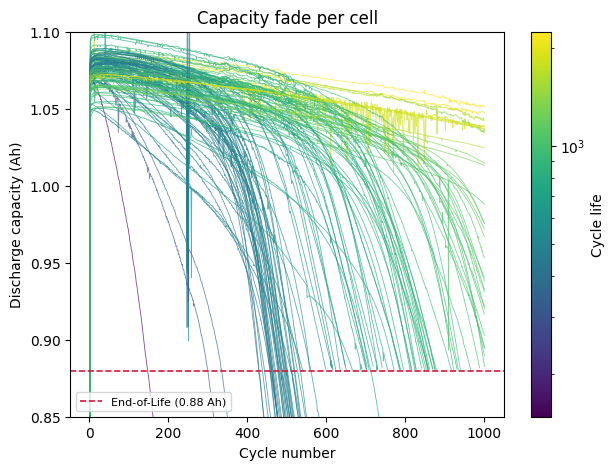

In [2]:
plots.plot_capacity_fade(ds); plt.show()

## 2. Cycle-life distribution

Cycle life ranges from ~150 to ~2300 and is **right-skewed** (a long tail of long-lived cells).
That skew is the reason we will regress on **log(cycle life)**: it makes the target roughly
symmetric, stabilizes variance, and means a fixed *percentage* error is penalized evenly across
short- and long-lived cells (which is what MAPE measures).

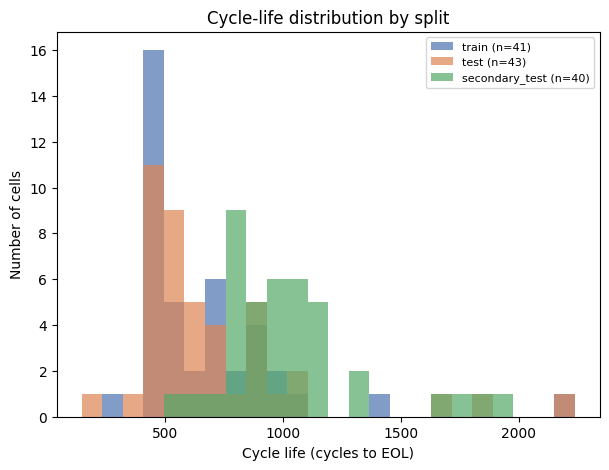

In [3]:
plots.plot_cycle_life_distribution(ds); plt.show()

## 3. ΔQ(V): the discharge-curve change between cycle 10 and 100

For each cell we take its discharge capacity-vs-voltage curve at cycle 100 and subtract the one
at cycle 10, on a fixed 1000-point voltage grid (2.0–3.5 V). This **ΔQ(V)** curve captures how the
*shape* of discharge shifts early in life. Cells that will fail soon (dark) show a larger, more
structured change than long-lived cells (yellow) — degradation leaves a fingerprint here long
before capacity fade is obvious in plot 1.

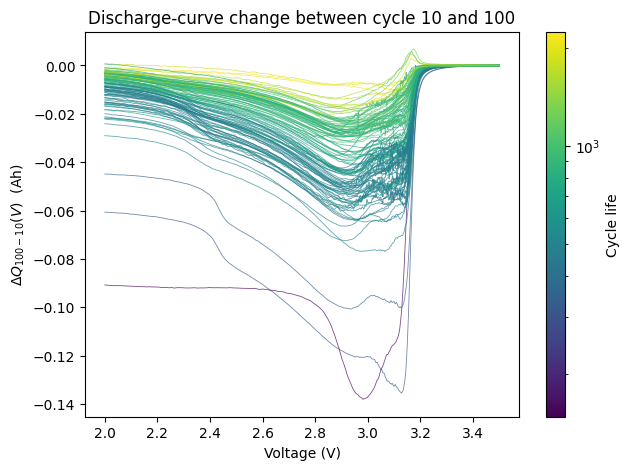

In [4]:
plots.plot_dqv_curves(ds); plt.show()

## 4. Why one feature works: var(ΔQ(V)) vs cycle life

Collapsing each ΔQ(V) curve to a single number — its **variance** — and plotting
$\log_{10}\mathrm{var}\,\Delta Q_{100-10}(V)$ against $\log_{10}$ cycle life reveals a tight, nearly
linear negative relationship (Pearson r ≈ −0.93). This is the heart of Severson et al. (2019):
a single, physically-motivated feature explains most of the variance in cycle life. It sets up the
**variance baseline model** in notebook 03 and is the honest floor every other model must beat.

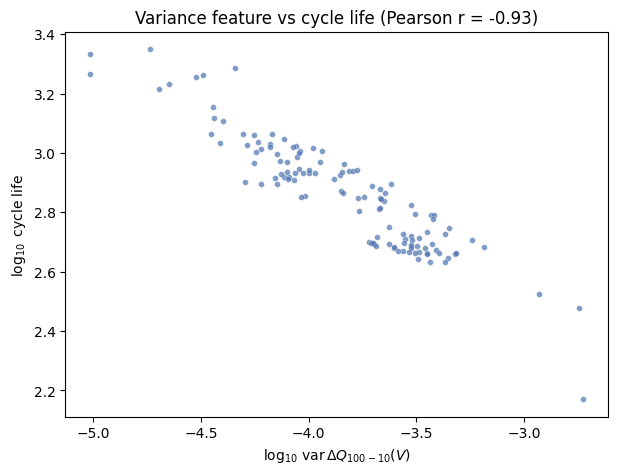

In [5]:
plots.plot_variance_vs_life(ds); plt.show()

## Takeaways for modeling

- **Predict log(cycle life)**, not raw cycle life (right-skewed target).
- The **variance of ΔQ(V)** is a strong single predictor → start there as a baseline.
- Respect the **train / primary-test / secondary-test** split (already encoded in `ds.cells['split']`) —
  the secondary test set is a *later manufacturing batch*, a genuine generalization check.
- Features must use **only the first ~100 cycles** to be useful for early screening.